In [52]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [53]:
pip install Wordcloud


  Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl (307 kB)


In [54]:
pip install Textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from wordcloud import WordCloud
from textblob import TextBlob



In [57]:
nltk.download('punkt', quiet=True)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Kimberly Elorm\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [58]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [59]:
with open("HKB.txt", 'r', encoding='utf-8') as file:
    text_data = file.read()

print("Text loaded successfully!")

Text loaded successfully!


In [60]:
print(text_data)

 C’était un homme de paix, un ancien président. C’est eux (avec Ouattara et Gbagbo) qui ont fait le pays, donc sa mort nous a vraiment surpris, ça nous a fait beaucoup de mal. 
C’était notre vieux père, nous sommes bouleversés. Moi je suis baoulé, c’était mon président. Mais tout le monde l’aime ici, les Malinké aussi. 
Ici il n’y a pas affaire de Dioula, Bété, Baoulé… Il n’y a pas ça. C’est notre papa à tous qui est décédé. 
Le président Bédié a vécu une vie tranquille et il est parti tranquillement. Le plus grand défi qui se pose à nous aujourd’hui, surtout aux soutiens du PDCI-RDA, c’est le défi du maintien de la cohésion et de l’unité. 
Nous sommes venus pour vous saluer, pour vous remercier pour tout. Depuis le décès du Président #Henri_Konan_Bédié, vous n'avez eu de cesse à être aux côtés de la famille. Je suis désigné par le PDCI-RDA pour assurer l'intérim du président Henri Konan Bédié. C'est donc un devoir pour moi de venir saluer, le Président de la République que vous êtes, 

In [61]:
import re

In [62]:
# Clean the text - remove citation markers [1], [2], etc.
text_clean = re.sub(r'\[\d+\]', '', text_data)

# Remove special characters but keep alphanumeric and basic punctuation
text_clean = re.sub(r'[^\w\s.,;:!?()-]', '', text_clean)

# Remove extra whitespace
text_clean = re.sub(r'\s+', ' ', text_clean)
text_clean = text_clean.strip()

print("Text after cleaning:")
print(f"Characters after cleaning: {len(text_clean)}")

Text after cleaning:
Characters after cleaning: 3031


In [63]:
sentences = sent_tokenize(text_clean)
print(f"Number of sentences: {len(sentences)}")
print(f"\nFirst 3 sentences:")
for i in range(min(3, len(sentences))):
    print(f"Sentence {i+1}: {sentences[i][:100]}...")
print("\n" + "="*80)

Number of sentences: 34

First 3 sentences:
Sentence 1: Cétait un homme de paix, un ancien président....
Sentence 2: Cest eux (avec Ouattara et Gbagbo) qui ont fait le pays, donc sa mort nous a vraiment surpris, ça no...
Sentence 3: Cétait notre vieux père, nous sommes bouleversés....



In [86]:
# Tokenization (Split into words)
words = word_tokenize(text_clean.lower())  # Convert to lowercase
print(f"Total words (including punctuation): {len(words)}")

# Filter alphanumeric words
words_alpha = [word for word in words if word.isalnum()]
print(f"Alphanumeric words only: {len(words_alpha)}")

# Show first 300 words
print(f"\nFirst 3000 words: {words_alpha[:3000]}")
print("\n" + "="*80)

Total words (including punctuation): 608
Alphanumeric words only: 544

First 3000 words: ['cétait', 'un', 'homme', 'de', 'paix', 'un', 'ancien', 'président', 'cest', 'eux', 'avec', 'ouattara', 'et', 'gbagbo', 'qui', 'ont', 'fait', 'le', 'pays', 'donc', 'sa', 'mort', 'nous', 'a', 'vraiment', 'surpris', 'ça', 'nous', 'a', 'fait', 'beaucoup', 'de', 'mal', 'cétait', 'notre', 'vieux', 'père', 'nous', 'sommes', 'bouleversés', 'moi', 'je', 'suis', 'baoulé', 'cétait', 'mon', 'président', 'mais', 'tout', 'le', 'monde', 'laime', 'ici', 'les', 'malinké', 'aussi', 'ici', 'il', 'ny', 'a', 'pas', 'affaire', 'de', 'dioula', 'bété', 'baoulé', 'il', 'ny', 'a', 'pas', 'ça', 'cest', 'notre', 'papa', 'à', 'tous', 'qui', 'est', 'décédé', 'le', 'président', 'bédié', 'a', 'vécu', 'une', 'vie', 'tranquille', 'et', 'il', 'est', 'parti', 'tranquillement', 'le', 'plus', 'grand', 'défi', 'qui', 'se', 'pose', 'à', 'nous', 'aujourdhui', 'surtout', 'aux', 'soutiens', 'du', 'cest', 'le', 'défi', 'du', 'maintien', 'de

In [65]:
stop_words_list = list(stopwords.words('french'))
print(f"Number of stop words in french: {len(stop_words_list)}")
print(f"Sample stop words: {stop_words_list[:10]}")

words_no_stop = []
for word in words_alpha:
    if word not in stop_words_list:
        words_no_stop.append(word)

print(f"\nWords before removing stop words: {len(words_alpha)}")
print(f"Words after removing stop words: {len(words_no_stop)}")
print(f"Percentage removed: {(len(words_alpha)-len(words_no_stop))/len(words_alpha)*100:.1f}%")
print("\n" + "="*80)

Number of stop words in french: 157
Sample stop words: ['au', 'aux', 'avec', 'ce', 'ces', 'dans', 'de', 'des', 'du', 'elle']

Words before removing stop words: 544
Words after removing stop words: 303
Percentage removed: 44.3%



In [66]:
# word frequencies before stopword removal
word_counts_before = Counter(words_alpha)
top_10_before = word_counts_before.most_common(30)
print("Top 10 most frequent words (before stopword removal):")
for word, count in top_10_before :
    print(f"  {word:15} : {count:4}")
print("\n" + "="*80)

Top 10 most frequent words (before stopword removal):
  de              :   26
  le              :   21
  président       :   14
  pour            :   13
  a               :   12
  la              :   12
  et              :   11
  un              :   10
  paix            :    9
  vous            :    9
  que             :    9
  les             :    8
  à               :    8
  du              :    8
  homme           :    7
  cest            :    7
  nous            :    7
  il              :    7
  bédié           :    7
  ce              :    7
  je              :    6
  cétait          :    5
  pays            :    5
  en              :    5
  qui             :    4
  fait            :    4
  moi             :    4
  suis            :    4
  tout            :    4
  des             :    4



In [67]:
# Stemming
stemmer = PorterStemmer()
stemmed_words = []
for word in words_no_stop[:30]: 
    stemmed_words.append(stemmer.stem(word))

print("Stemming Examples (first 30 words):")
for i in range(min(20, len(words_no_stop))):
    original =  words_no_stop[i]
    stemmed = stemmer.stem(original)
    print(f"  {original:15} -> {stemmed}")
print("\n" + "="*80)

Stemming Examples (first 30 words):
  cétait          -> cétait
  homme           -> homm
  paix            -> paix
  ancien          -> ancien
  président       -> président
  cest            -> cest
  ouattara        -> ouattara
  gbagbo          -> gbagbo
  fait            -> fait
  pays            -> pay
  donc            -> donc
  mort            -> mort
  a               -> a
  vraiment        -> vraiment
  surpris         -> surpri
  ça              -> ça
  a               -> a
  fait            -> fait
  beaucoup        -> beaucoup
  mal             -> mal



In [68]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_words = []
for word in words_no_stop[:30]:  # Just lemmatize first 20 for demonstration
    lemmatized_words.append(lemmatizer.lemmatize(word))

print("Lemmatization Examples (first 30 words):")
for i in range(min(30, len(words_no_stop))):
    original = words_no_stop[i]
    lemmatized = lemmatizer.lemmatize(original)
    print(f"  {original:15} -> {lemmatized}")
print("\n" + "="*80)

Lemmatization Examples (first 30 words):
  cétait          -> cétait
  homme           -> homme
  paix            -> paix
  ancien          -> ancien
  président       -> président
  cest            -> cest
  ouattara        -> ouattara
  gbagbo          -> gbagbo
  fait            -> fait
  pays            -> pay
  donc            -> donc
  mort            -> mort
  a               -> a
  vraiment        -> vraiment
  surpris         -> surpris
  ça              -> ça
  a               -> a
  fait            -> fait
  beaucoup        -> beaucoup
  mal             -> mal
  cétait          -> cétait
  vieux           -> vieux
  père            -> père
  bouleversés     -> bouleversés
  baoulé          -> baoulé
  cétait          -> cétait
  président       -> président
  tout            -> tout
  monde           -> monde
  laime           -> laime



In [69]:
# Part-of-Speech Tagging
pos_tags = pos_tag(words_no_stop[:50])  # Tag first 50 words
print("Part-of-Speech Tagging (first 50 words):")
print("-" * 40)
for i in range(0, len(pos_tags), 5):
    batch = pos_tags[i:i+5]
    for word, tag in batch:
        print(f"  {word:15} : {tag:5}", end="  ")
    print()
print("\n" + "="*80)

Part-of-Speech Tagging (first 50 words):
----------------------------------------
  cétait          : NN       homme           : NN       paix            : NN       ancien          : JJ       président       : NN     
  cest            : JJS      ouattara        : NN       gbagbo          : NN       fait            : NN       pays            : VBZ    
  donc            : VB       mort            : NN       a               : DT       vraiment        : JJ       surpris         : NN     
  ça              : VBD      a               : DT       fait            : NN       beaucoup        : NN       mal             : JJ     
  cétait          : NN       vieux           : NN       père            : NN       bouleversés     : NN       baoulé          : NN     
  cétait          : NN       président       : NN       tout            : IN       monde           : NN       laime           : NN     
  ici             : NN       malinké         : NN       aussi           : NN       ici             : N

In [70]:
# Term Frequency (TF) - Count word frequencies after stopword removal
word_counts = Counter(words_no_stop)
top_20_words = word_counts.most_common(20)

print("Top 20 Most Frequent Words (after stopword removal):")
print("-" * 40)
for i, (word, count) in enumerate(top_20_words, 1):
    print(f"{i:2}. {word:15} : {count:3}")
print("\n" + "="*80)

Top 20 Most Frequent Words (after stopword removal):
----------------------------------------
 1. président       :  14
 2. a               :  12
 3. paix            :   9
 4. homme           :   7
 5. cest            :   7
 6. bédié           :   7
 7. cétait          :   5
 8. pays            :   5
 9. fait            :   4
10. tout            :   4
11. ivoiriens       :   4
12. après           :   4
13. remercier       :   3
14. famille         :   3
15. konan           :   3
16. liens           :   3
17. merci           :   3
18. pépé            :   3
19. repose          :   3
20. politique       :   3



In [71]:
# Prepare paragraphs for TF-IDF
# Split text into paragraphs (by double newlines)
paragraphs_raw = text_clean.split("\n\n")
paragraphs = []
for para in paragraphs_raw:
    para_clean = para.strip()
    if para_clean and len(para_clean.split()) > 3:  # Remove empty or very short paragraphs
        paragraphs.append(para_clean)

print(f"Number of paragraphs: {len(paragraphs)}")
print(f"\nFirst 2 paragraphs:")
for i in range(min(2, len(paragraphs))):
    print(f"\nParagraph {i+1} (first 100 chars):")
    print(f"{paragraphs[i][:100]}...")
print("\n" + "="*80)

Number of paragraphs: 1

First 2 paragraphs:

Paragraph 1 (first 100 chars):
Cétait un homme de paix, un ancien président. Cest eux (avec Ouattara et Gbagbo) qui ont fait le pay...



In [72]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=15, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(paragraphs)
feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF Features (Top 15):")
print(feature_names)
print("\nTF-IDF Matrix Shape:", tfidf_matrix.shape)

# Calculate average TF-IDF score for each word
tfidf_scores = tfidf_matrix.mean(axis=0).A1
word_score_pairs = []
for i in range(len(feature_names)):
    word_score_pairs.append((feature_names[i], tfidf_scores[i]))

# Sort by score
word_score_pairs.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 words by TF-IDF score:")
for i, (word, score) in enumerate(word_score_pairs[:10], 1):
    print(f"{i:2}. {word:15} : {score:.4f}")
print("\n" + "="*80)

TF-IDF Features (Top 15):
['bédié' 'ce' 'du' 'et' 'homme' 'il' 'la' 'le' 'les' 'nous' 'paix' 'pour'
 'président' 'que' 'vous']

TF-IDF Matrix Shape: (1, 15)

Top 10 words by TF-IDF score:
 1. le              : 0.5090
 2. président       : 0.3394
 3. pour            : 0.3151
 4. la              : 0.2909
 5. et              : 0.2666
 6. paix            : 0.2182
 7. que             : 0.2182
 8. vous            : 0.2182
 9. du              : 0.1939
10. il              : 0.1939



In [73]:
# Bag of Words (Count Vectorizer)
count_vectorizer = CountVectorizer(max_features=15, stop_words='english')
count_matrix = count_vectorizer.fit_transform(paragraphs)
count_features = count_vectorizer.get_feature_names_out()

print("Bag of Words Features (Top 15):")
print(count_features)
print("\nDocument-Term Matrix Shape:", count_matrix.shape)

# Sum counts across all documents
word_counts_bow = count_matrix.sum(axis=0).A1
bow_pairs = []
for i in range(len(count_features)):
    bow_pairs.append((count_features[i], word_counts_bow[i]))

# Sort by count
bow_pairs.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 words by BoW frequency:")
for i, (word, count) in enumerate(bow_pairs[:10], 1):
    print(f"{i:2}. {word:15} : {count:3}")
print("\n" + "="*80)

Bag of Words Features (Top 15):
['bédié' 'ce' 'du' 'et' 'homme' 'il' 'la' 'le' 'les' 'nous' 'paix' 'pour'
 'président' 'que' 'vous']

Document-Term Matrix Shape: (1, 15)

Top 10 words by BoW frequency:
 1. le              :  21
 2. président       :  14
 3. pour            :  13
 4. la              :  12
 5. et              :  11
 6. paix            :   9
 7. que             :   9
 8. vous            :   9
 9. du              :   8
10. il              :   8



In [74]:
# Sentiment Analysis
sentiment_scores = []
for sentence in sentences:
    blob = TextBlob(sentence)
    sentiment_scores.append(blob.sentiment.polarity)

# Calculate statistics
avg_sentiment = sum(sentiment_scores) / len(sentiment_scores)
max_sentiment = max(sentiment_scores)
min_sentiment = min(sentiment_scores)
max_sentiment_idx = sentiment_scores.index(max_sentiment)
min_sentiment_idx = sentiment_scores.index(min_sentiment)

print("Sentiment Analysis Results:")
print("-" * 40)
print(f"Average sentiment: {avg_sentiment:.4f}")
print(f"Most positive sentence (score: {max_sentiment:.4f}):")
print(f"  '{sentences[max_sentiment_idx][:100]}...'")
print(f"\nMost negative sentence (score: {min_sentiment:.4f}):")
print(f"  '{sentences[min_sentiment_idx][:100]}...'")
print(f"\nNumber of positive sentences (score > 0.1): {len([s for s in sentiment_scores if s > 0.1])}")
print(f"Number of negative sentences (score < -0.1): {len([s for s in sentiment_scores if s < -0.1])}")
print(f"Number of neutral sentences: {len([s for s in sentiment_scores if -0.1 <= s <= 0.1])}")
print("\n" + "="*80)

Sentiment Analysis Results:
----------------------------------------
Average sentiment: 0.0294
Most positive sentence (score: 0.5000):
  'Le plus grand défi qui se pose à nous aujourdhui, surtout aux soutiens du PDCI-RDA, cest le défi du ...'

Most negative sentence (score: 0.0000):
  'Cétait un homme de paix, un ancien président....'

Number of positive sentences (score > 0.1): 2
Number of negative sentences (score < -0.1): 0
Number of neutral sentences: 32



In [77]:
# Topic Modeling - Simple keyword frequency approach
# Define keywords for different topics
topic_keywords = {
    'affinité': ['grand homme', 'ivoirien', 'pépé', 'papa','papi', 'président'],
    'qualité': ['bon', 'paix', 'cohésion','amour','politique','merci'],
    'nom': ['henri', 'konan', 'bedie','lui']
}

# Count occurrences of each topic's keywords
topic_scores = {}
for topic, keywords in topic_keywords.items():
    score = 0
    for keyword in keywords:
        # Count in cleaned text (case insensitive)
        count = len(re.findall(r'\b' + keyword + r'\b', text_clean.lower()))
        score += count
    topic_scores[topic] = score

# Sort topics by score
sorted_topics = sorted(topic_scores.items(), key=lambda x: x[1], reverse=True)

print("Topic Modeling Results (Keyword-based):")
print("-" * 40)
for topic, score in sorted_topics:
    display_name = topic.replace('_', ' ').title()
    print(f"{display_name:20} : {score:3} occurrences")
print("\n" + "="*80)

Topic Modeling Results (Keyword-based):
----------------------------------------
Affinité             :  21 occurrences
Qualité              :  16 occurrences
Nom                  :  10 occurrences



Text(0.5, 1.0, 'Word Cloud')

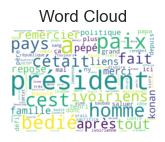

In [84]:
ax2 = plt.subplot(3, 3, 2)
wordcloud = WordCloud(width=1000, height=700, background_color='white',
                      max_words=100, colormap='viridis').generate_from_frequencies(word_counts)
ax2.imshow(wordcloud, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Word Cloud')

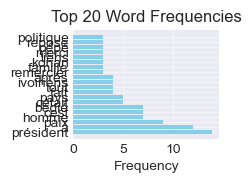

In [93]:
ax1 = plt.subplot(3, 3, 1)
words, counts = zip(*top_20_words)
ax1.barh(words, counts, color='skyblue')
ax1.set_xlabel('Frequency')
ax1.set_title('Top 20 Word Frequencies')
ax1.grid(True, alpha=0.5)

Text(0.5, 1.0, 'Text Statistics')

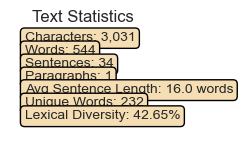

In [92]:
ax5 = plt.subplot(3, 3, 5)
ax5.axis('off')
stats_text = [
    f"Characters: {len(text_clean):,}",
    f"Words: {len(words_alpha):,}",
    f"Sentences: {len(sentences):,}",
    f"Paragraphs: {len(paragraphs):,}",
    f"Avg Sentence Length: {len(words_alpha)/len(sentences):.1f} words",
    f"Unique Words: {len(set(words_alpha)):,}",
    f"Lexical Diversity: {len(set(words_alpha))/len(words_alpha):.2%}"
]
for i, stat in enumerate(stats_text):
    ax5.text(0.1, 0.9 - i*0.12, stat, fontsize=10, transform=ax5.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=1))
ax5.set_title('Text Statistics')